In [1]:
import rebayes_mini
import jax
jax.config.update("jax_enable_x64", True)
import chex
import numpy as np
import pandas as pd
import seaborn as sns
import jax.numpy as jnp
import matplotlib.pyplot as plt
from functools import partial
from rebayes_mini import callbacks
from rebayes_mini.states import GaussState
import pickle, os, sys, time, platform
from tqdm import tqdm

from profilter import ExtendedKalmanFilter
from profilter_rebuttal import PrOFilter
from unscented import UnscentedKalmanFilter, UKFPrOFilterPred, CubatureKalmanFilter, CKFPrOFilterPred

cmap = {
    "EKF": "lightseagreen",
    "UKF": "teal",
    "CKF": "slateblue",
    "EKF-PrO": "mediumorchid",
    "UKF-PrO": "deeppink",
    "CKF-PrO": "darkgoldenrod",
}

def euler_step(y, i, dt, f):
    h = dt
    t = dt * i
    k1 = h * f(y, t, i)
    return y + k1

def rk4_step(y, i, dt, f):
    h = dt
    t = dt * i
    k1 = h * f(y, t, i)
    k2 = h * f(y + k1 / 2, dt * i + h / 2, i)
    k3 = h * f(y + k2 / 2, t + h / 2, i)
    k4 = h * f(y + k3, t + h, i)

    y_next = y + 1 / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return y_next

@partial(jax.jit, static_argnames=("f",))
def solve(ys, dt, N, f):
    @jax.jit
    def step(i, ys):
        ysi = euler_step(ys[i - 1], i, dt, f)
        return ys.at[i].set(ysi)
    return jax.lax.fori_loop(1, N, step, ys)

In [2]:
def get_environment_info():
    return {
        "python_version": sys.version,
        "platform": platform.platform(),
        "processor": platform.processor(),
        "jax_version": jax.__version__,
        "jax_backend": jax.default_backend(),
        "numpy_version": np.__version__,
    }

env_info = get_environment_info()
print(env_info)

{'python_version': '3.11.5 (main, Aug  4 2026, 12:20:09) [Clang 17.0.0 (clang-1700.0.13.5)]', 'platform': 'macOS-15.7.9-x86_64-i386-64bit', 'processor': 'i386', 'jax_version': '0.4.38', 'jax_backend': 'cpu', 'numpy_version': '2.3.5'}


In [3]:
D = 60
N = 10000
dt = 0.002
sigma = 1.0
F = 8.0
n_hidden = 2
transition_prob = 0.995
observation_covariance = 5.0

@partial(jax.vmap, in_axes=(None, 0, None))
def fcoord(x, k, D):
    xdot = (x[(k + 1) % D] - x[k - 2]) * x[k - 1] - x[k] + F
    return xdot

def generate_data(seed):
    key = jax.random.PRNGKey(seed)
    key_init, key_sim, key_eval = jax.random.split(key, 3)
    key_state, key_measurement = jax.random.split(key_sim)

    key_hidden, key_state = jax.random.split(key_state)
    transition_state = jnp.ones((n_hidden, n_hidden)) * 1/(n_hidden-1) * (1-transition_prob)
    transition_state = transition_state.at[jnp.diag_indices_from(transition_state)].set(transition_prob)

    key_hidden, key_state = jax.random.split(key_state)
    phi_hidden = jax.random.normal(key_hidden, (D, n_hidden-1)) * sigma
    phi_hidden = jnp.concatenate([jnp.zeros((D, 1)), phi_hidden], -1)

    @jax.jit
    def f(x, t, i, regime):
        keyt = jax.random.fold_in(key_state, i)
        key_regime, keyt = jax.random.split(keyt)
        probabilities = transition_state[regime, :]
        logits = jnp.log(probabilities)
        regime_next = jax.random.categorical(key_regime, logits)
        ixs = jnp.arange(D)
        xdot = fcoord(x, ixs, D) + phi_hidden[:, regime_next]
        return xdot, regime_next

    x0 = jax.random.normal(key_init, (D,))
    x_init = jnp.copy(x0)
    xs = jnp.zeros((N,) + x0.shape)
    xs = xs.at[0].set(x0)
    regime = int(0)
    for i in range(1, N):
        xdot, regime = f(x0, i * dt, i, regime)
        x0 = x0 + dt * xdot
        xs = xs.at[i].set(x0)

    ys = xs + jnp.sqrt(observation_covariance) * jax.random.normal(key_measurement, xs.shape)
    return xs, ys, x_init

def latent_fn(x):
    @jax.jit
    def f(x, t, _):
        ixs = jnp.arange(D)
        return fcoord(x, ixs, D) + 0.01 * jnp.sin(100 * x)
    return euler_step(x, 0, dt, f)

def obs_fn(x, _):
    return x

def get_mean_and_cov(bel, bel_pred, y, x):
    return bel.mean, bel.cov

def nll_step(x_true, mean, cov):
    d = mean.shape[0]
    diff = x_true - mean
    sign, logdet = jnp.linalg.slogdet(cov)
    quad = diff @ jnp.linalg.solve(cov, diff)
    return 0.5 * (quad + logdet + d * jnp.log(2 * jnp.pi))

In [4]:
def run_all_filters(xs, ys, x_init):
    nsteps = xs.shape[0]
    results = {}

    configs = [
        ("EKF", ExtendedKalmanFilter, {}),
        ("EKF-PrO", PrOFilter, {"n_inner": 5, "n_outer": 10}),
        ("UKF", UnscentedKalmanFilter, {}),
        ("UKF-PrO", UKFPrOFilterPred, {"n_inner": 5, "n_outer": 10}),
        ("CKF", CubatureKalmanFilter, {}),
        ("CKF-PrO", CKFPrOFilterPred, {"n_inner": 5, "n_outer": 10}),
    ]

    for method, cls, kwargs in configs:
        t0_method = time.time()

        agent = cls(
            latent_fn, obs_fn,
            dynamics_covariance=jnp.eye(D) * jnp.square(sigma * dt),
            observation_covariance=observation_covariance * jnp.eye(D),
            **kwargs,
        )
        init_bel = agent.init_bel(x_init, cov=1.0)
        filterfn = partial(agent.scan, callback_fn=get_mean_and_cov)
        _, (hist, hist_cov) = filterfn(init_bel, ys, jnp.ones(nsteps))

        if not jnp.all(jnp.isfinite(hist)):
            print(f"WARNING: non-finite values for method {method}")

        mse = jnp.sum(jnp.square(hist - xs))
        nll_per_step = jax.vmap(nll_step)(xs, hist, hist_cov)

        method_time = time.time() - t0_method

        results[method] = {
            "mse": float(mse),
            "mean_nll": float(jnp.mean(nll_per_step)),
            "wall_clock_seconds": method_time,
        }

    return results

In [5]:
seed_list = list(range(1, 101))

results_file = "lorenz_oscillating_results.pkl"
all_results = {} #pickle.load(open(results_file, "rb")) if os.path.exists(results_file) else {}

for seed in tqdm(seed_list):
    #if seed in all_results:
        #continue

    t0 = time.time()
    xs_s, ys_s, x_init_s = generate_data(seed)
    seed_results = run_all_filters(xs_s, ys_s, x_init_s)
    wall_clock_time = time.time() - t0

    seed_results["_wall_clock_seconds"] = wall_clock_time
    seed_results["_environment"] = env_info

    all_results[seed] = seed_results
    pickle.dump(all_results, open(results_file, "wb"))
    print(f"Seed {seed}: {wall_clock_time:.1f}s")

print(f"Completed {len(all_results)} / {len(seed_list)} seeds.")

  1%|          | 1/100 [11:25<18:51:13, 685.59s/it]

Seed 1: 685.6s


  2%|▏         | 2/100 [23:01<18:50:06, 691.91s/it]

Seed 2: 696.3s


  3%|▎         | 3/100 [34:55<18:54:56, 702.02s/it]

...

Seed 98: 688.3s


 99%|█████████▉| 99/100 [18:42:19<11:21, 681.06s/it]

Seed 99: 672.0s


100%|██████████| 100/100 [18:53:44<00:00, 680.24s/it]

Seed 100: 685.0s
Completed 100 / 100 seeds.


In [6]:
timings = [all_results[s]["_wall_clock_seconds"] for s in all_results]
print(f"Mean time per seed: {np.mean(timings):.1f}s ({np.mean(timings)/60:.1f} min)")
print(f"Total time: {np.sum(timings):.1f}s ({np.sum(timings)/60:.1f} min)")
print(f"Environment: {env_info}")

Mean time per seed: 680.2s (11.3 min)
Total time: 68023.8s (1133.7 min)
Environment: {'python_version': '3.11.5 (main, Aug  4 2026, 12:20:09) [Clang 17.0.0 (clang-1700.0.13.5)]', 'platform': 'macOS-15.7.9-x86_64-i386-64bit', 'processor': 'i386', 'jax_version': '0.4.38', 'jax_backend': 'cpu', 'numpy_version': '2.3.5'}


/var/folders/r4/p062074s47bd8mh7y8k7qhy40000gn/T/ipykernel_64844/2945602138.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(y="error", x="method", data=mse_df, palette=cmap, order=methods)
/var/folders/r4/p062074s47bd8mh7y8k7qhy40000gn/T/ipykernel_64844/2945602138.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(y="error", x="method", data=nll_df, palette=cmap, order=methods)


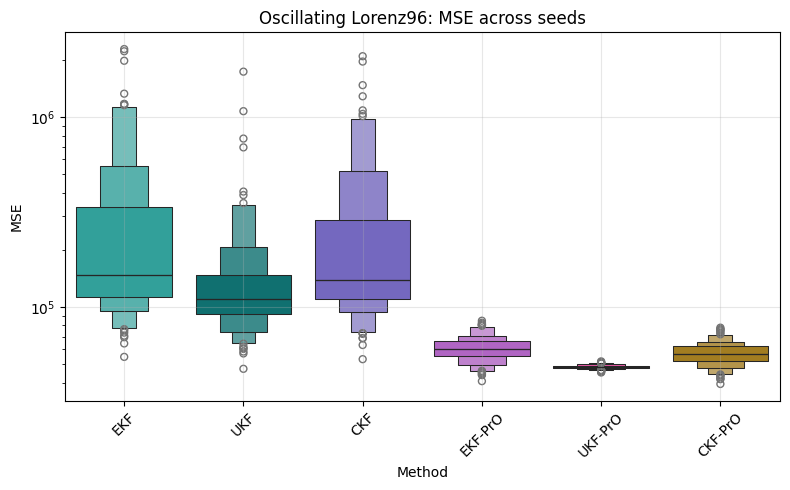

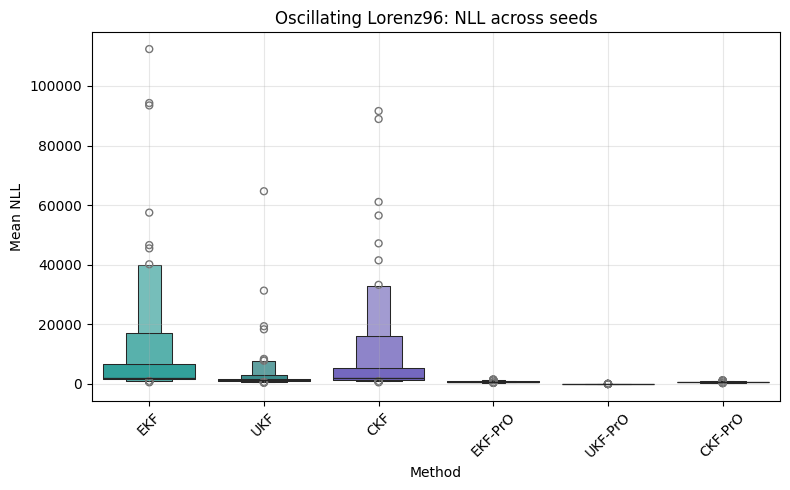

In [7]:
methods = ["EKF", "UKF", "CKF", "EKF-PrO", "UKF-PrO", "CKF-PrO"]

mse_rows = [{"method": m, "seed": s, "error": all_results[s][m]["mse"]}
            for m in methods for s in all_results]
nll_rows = [{"method": m, "seed": s, "error": all_results[s][m]["mean_nll"]}
            for m in methods for s in all_results]

mse_df = pd.DataFrame(mse_rows)
nll_df = pd.DataFrame(nll_rows)

plt.figure(figsize=(8, 5))
sns.boxenplot(y="error", x="method", data=mse_df, palette=cmap, order=methods)
plt.xlabel("Method"); plt.ylabel("MSE"); plt.grid(alpha=0.3); plt.yscale("log")
plt.title("Oscillating Lorenz96: MSE across seeds"); plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig("lorenz_oscillating_mse.pdf")
mse_df.to_csv("lorenz_oscillating_mse.csv", index=False)

plt.figure(figsize=(8, 5))
sns.boxenplot(y="error", x="method", data=nll_df, palette=cmap, order=methods)
plt.xlabel("Method"); plt.ylabel("Mean NLL"); plt.grid(alpha=0.3)
plt.title("Oscillating Lorenz96: NLL across seeds"); plt.xticks(rotation=45)
plt.tight_layout(); plt.savefig("lorenz_oscillating_nll.pdf")
nll_df.to_csv("lorenz_oscillating_nll.csv", index=False)

In [ ]:
import pickle

with open("lorenz_oscillating_results.pkl", "rb") as f:
    all_results = pickle.load(f)

methods = ["EKF", "UKF", "CKF", "EKF-PrO", "UKF-PrO", "CKF-PrO"]
seeds_completed = sorted(all_results.keys())

print(f"Seeds completed: {len(seeds_completed)}")
print(f"Seed list: {seeds_completed}")
print()

for m in methods:
    mses = [all_results[s][m]["mse"] for s in seeds_completed]
    nlls = [all_results[s][m]["mean_nll"] for s in seeds_completed]

    print(f"{m}:")
    print(f"  MSE  -> mean={np.mean(mses):.4f}, std={np.std(mses):.4f}, min={np.min(mses):.4f}, max={np.max(mses):.4f}")
    print(f"  NLL  -> mean={np.mean(nlls):.4f}, std={np.std(nlls):.4f}, min={np.min(nlls):.4f}, max={np.max(nlls):.4f}")
    print()

timings = [all_results[s]["_wall_clock_seconds"] for s in seeds_completed]
print(f"Timing -> mean={np.mean(timings):.1f}s, total={np.sum(timings)/3600:.2f} hours")

Seeds completed: 100
Seed list: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]

EKF:
  MSE  -> mean=313695.2947, std=415959.6625, min=54680.3496, max=2281685.5739
  NLL  -> mean=9548.4928, std=19257.8419, min=548.1482, max=112350.2063

UKF:
  MSE  -> mean=164811.3289, std=211862.0889, min=47318.5946, max=1735296.0214
  NLL  -> mean=2936.7275, std=7408.9389, min=381.1620, max=64655.6399

CKF:
  MSE  -> mean=286788.2163, std=366017.2389, min=53186.9920, max=2093028.5685
  NLL  -> mean=8303.4223, std=16316.7816, min=525.4963, max=91564.6142

EKF-PrO:
  MSE  -> mean=60586.8280, std=9223.3350, min=40745.1824, max=84735.2422
  NLL  -> mean=824.4842, st

/var/folders/r4/p062074s47bd8mh7y8k7qhy40000gn/T/ipykernel_64844/489929866.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(y="error", x="method", data=nll_df[nll_df.method.isin(plain_methods)],
/var/folders/r4/p062074s47bd8mh7y8k7qhy40000gn/T/ipykernel_64844/489929866.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(y="error", x="method", data=nll_df[nll_df.method.isin(pro_methods)],


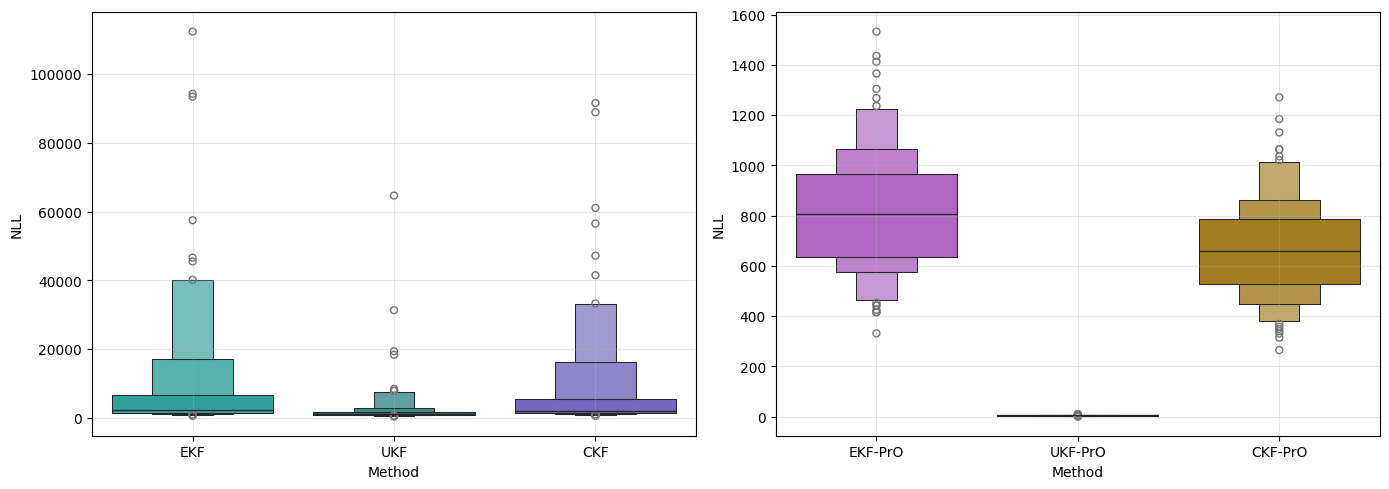

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plain_methods = ["EKF", "UKF", "CKF"]
pro_methods = ["EKF-PrO", "UKF-PrO", "CKF-PrO"]

sns.boxenplot(y="error", x="method", data=nll_df[nll_df.method.isin(plain_methods)],
              palette=cmap, order=plain_methods, ax=axes[0])
axes[0].set_ylabel("NLL")
axes[0].set_xlabel("Method")
axes[0].grid(alpha=0.3)

sns.boxenplot(y="error", x="method", data=nll_df[nll_df.method.isin(pro_methods)],
              palette=cmap, order=pro_methods, ax=axes[1])
axes[1].set_ylabel("NLL")
axes[1].set_xlabel("Method")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("lorenz_oscillating_nll2.pdf")
plt.show()

In [10]:
methods = ["EKF", "UKF", "CKF", "EKF-PrO", "UKF-PrO", "CKF-PrO"]

for m in methods:
    times = [all_results[s][m]["wall_clock_seconds"] for s in all_results if "wall_clock_seconds" in all_results[s][m]]
    if times:
        print(f"{m}: mean = {np.mean(times):.2f}s, std = {np.std(times):.2f}s")
    else:
        print(f"{m}: no per-method timing recorded")

EKF: mean = 3.05s, std = 0.34s
UKF: mean = 6.41s, std = 0.21s
CKF: mean = 6.44s, std = 0.22s
EKF-PrO: mean = 154.65s, std = 5.34s
UKF-PrO: mean = 310.49s, std = 9.40s
CKF-PrO: mean = 159.97s, std = 5.05s


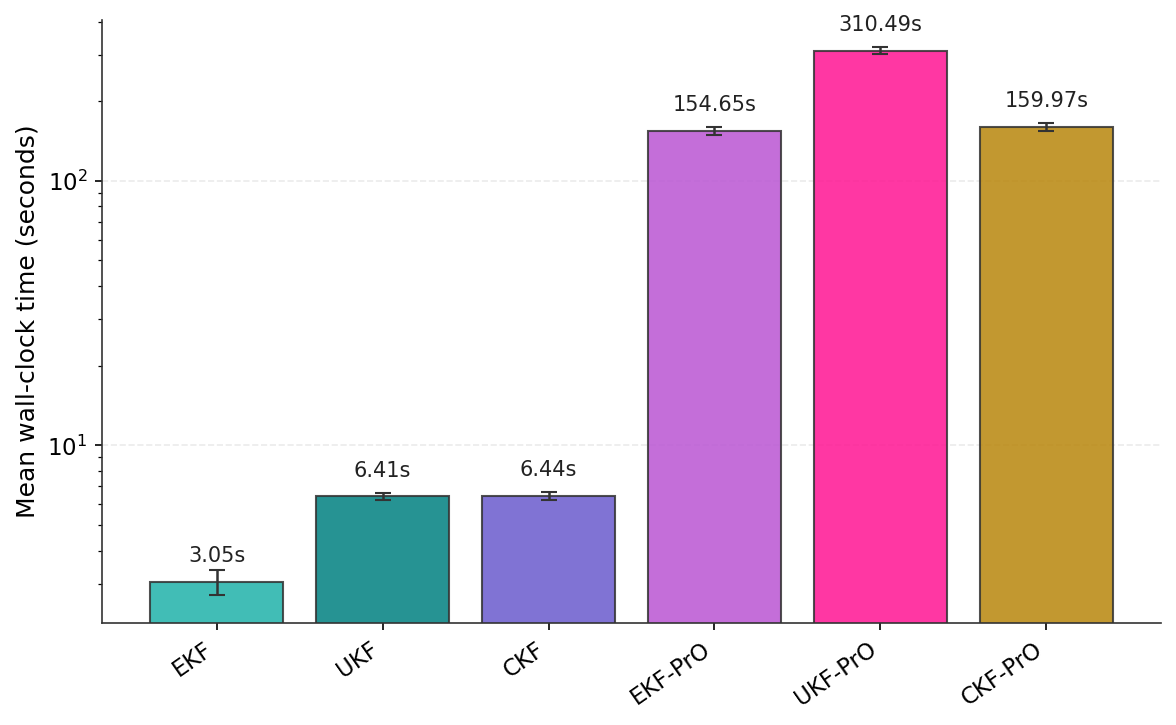

In [21]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#333333",
})

methods = ["EKF", "UKF", "CKF", "EKF-PrO", "UKF-PrO", "CKF-PrO"]

timing_rows = []
for m in methods:
    for s in all_results:
        if "wall_clock_seconds" in all_results[s][m]:
            timing_rows.append({"method": m, "seed": s, "time": all_results[s][m]["wall_clock_seconds"]})

timing_df = pd.DataFrame(timing_rows)

means = [timing_df[timing_df.method == m]["time"].mean() for m in methods]
stds = [timing_df[timing_df.method == m]["time"].std() for m in methods]

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

bars = ax.bar(
    methods, means, yerr=stds, capsize=4,
    color=[cmap[m] for m in methods], alpha=0.85,
    edgecolor="#333333", linewidth=1.0,
    error_kw=dict(elinewidth=1.2, ecolor="#333333"),
)

ax.set_ylabel("Mean wall-clock time (seconds)", fontsize=12)
ax.set_yscale("log")
ax.grid(alpha=0.25, axis='y', linestyle='--')
ax.set_axisbelow(True)
ax.tick_params(axis='x', rotation=35, labelsize=11)
ax.tick_params(axis='y', labelsize=11)
for label in ax.get_xticklabels():
    label.set_ha('right')

# Value labels above each bar
for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.15,
        f"{mean:.2f}s",
        ha='center', va='bottom', fontsize=10, color="#222222",
    )

plt.tight_layout()
plt.savefig("lorenz_oscillating_timing.pdf", bbox_inches='tight', dpi=300)
plt.show()

Min NLL per method:
  EKF-PrO: 331.2397
  UKF-PrO: 0.3012
  CKF-PrO: 264.7002


/var/folders/r4/p062074s47bd8mh7y8k7qhy40000gn/T/ipykernel_64844/2592301833.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(y="error", x="method", data=nll_df[nll_df.method.isin(pro_methods)],


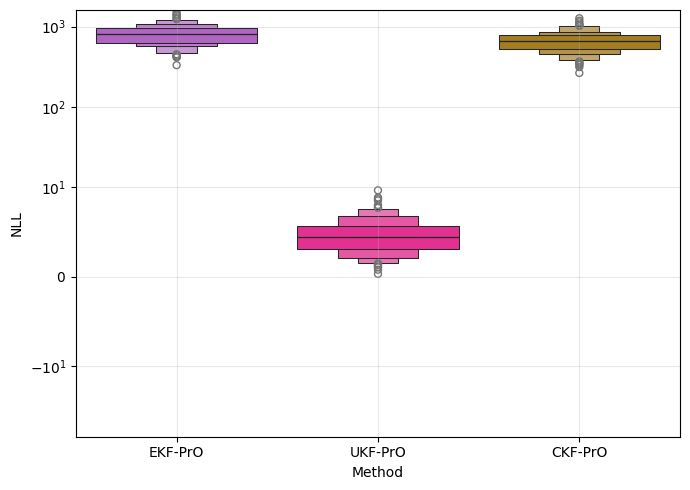

In [19]:
pro_methods = ["EKF-PrO", "UKF-PrO", "CKF-PrO"]

# Check for non-positive values before applying any log-based scale
print("Min NLL per method:")
for m in pro_methods:
    print(f"  {m}: {nll_df[nll_df.method==m]['error'].min():.4f}")

plt.figure(figsize=(7, 5))
sns.boxenplot(y="error", x="method", data=nll_df[nll_df.method.isin(pro_methods)],
              palette=cmap, order=pro_methods)
plt.ylabel("NLL")
plt.xlabel("Method")
plt.grid(alpha=0.3)
plt.yscale("symlog", linthresh=10)
plt.tight_layout()
plt.savefig("lorenz_oscillating_nll_pro_symlog.pdf")
plt.show()